# Car Price Prediction — Standardized ML Pipeline

Predict a used car's **selling price** (regression) with a clean, leakage-free pipeline.

**Pipeline order:** Basic Analysis -> Train/Test Split -> EDA -> Feature Engineering -> Encoding -> Outlier Handling -> Scaling -> Models.

> Every data-driven step (encoding categories, outlier bounds, scaler) is fit on the **training set only** and applied to test, to prevent data leakage.

## 0. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from scipy import stats
from scipy.stats.mstats import winsorize

sns.set()

## 1. Basic Analysis

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Study/Jhankar Mahbub/Phitron ML AI/Main course/ML without git/ML practice self/Machine Learning Projects/Regression/Car Price Prediction/car data.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
print('Shape:', df.shape)
df.info()

Shape: (4340, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [5]:
df.describe(include='all')

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
count,4340,4340.000000,4.340000e+03,4340.000000,4340,4340,4340,4340
unique,1491,NaN,NaN,NaN,5,3,2,5
top,Maruti Swift Dzire VDI,NaN,NaN,NaN,Diesel,Individual,Manual,First Owner
freq,69,NaN,NaN,NaN,2153,3244,3892,2832
mean,NaN,2013.090783,5.041273e+05,66215.777419,NaN,NaN,NaN,NaN
std,NaN,4.215344,5.785487e+05,46644.102194,NaN,NaN,NaN,NaN
min,NaN,1992.000000,2.000000e+04,1.000000,NaN,NaN,NaN,NaN
25%,NaN,2011.000000,2.087498e+05,35000.000000,NaN,NaN,NaN,NaN
50%,NaN,2014.000000,3.500000e+05,60000.000000,NaN,NaN,NaN,NaN
75%,NaN,2016.000000,6.000000e+05,90000.000000,NaN,NaN,NaN,NaN


In [6]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


## 2. Train-Test Split (done early to prevent data leakage)

In [7]:
X = df.drop(columns='selling_price')
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (3472, 7) | Test: (868, 7)


## 3. EDA (training data only)

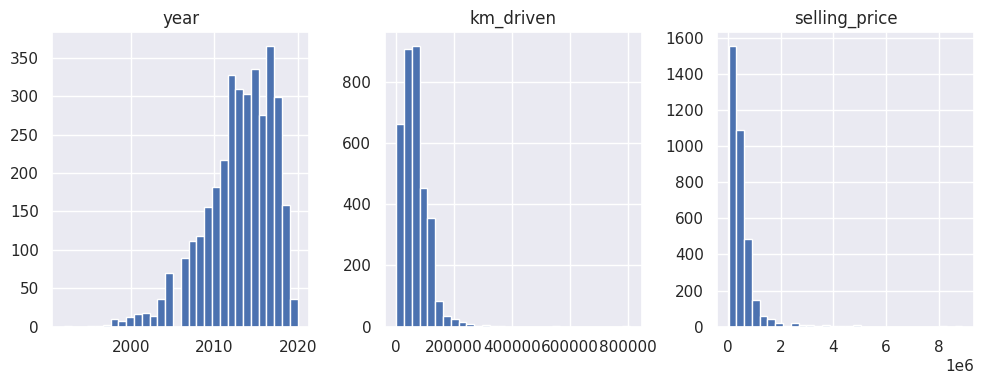

In [8]:
train_df = X_train.copy()
train_df['selling_price'] = y_train

train_df[['year', 'km_driven', 'selling_price']].hist(figsize=(10, 4), bins=30, layout=(1, 3))
plt.tight_layout()
plt.show()

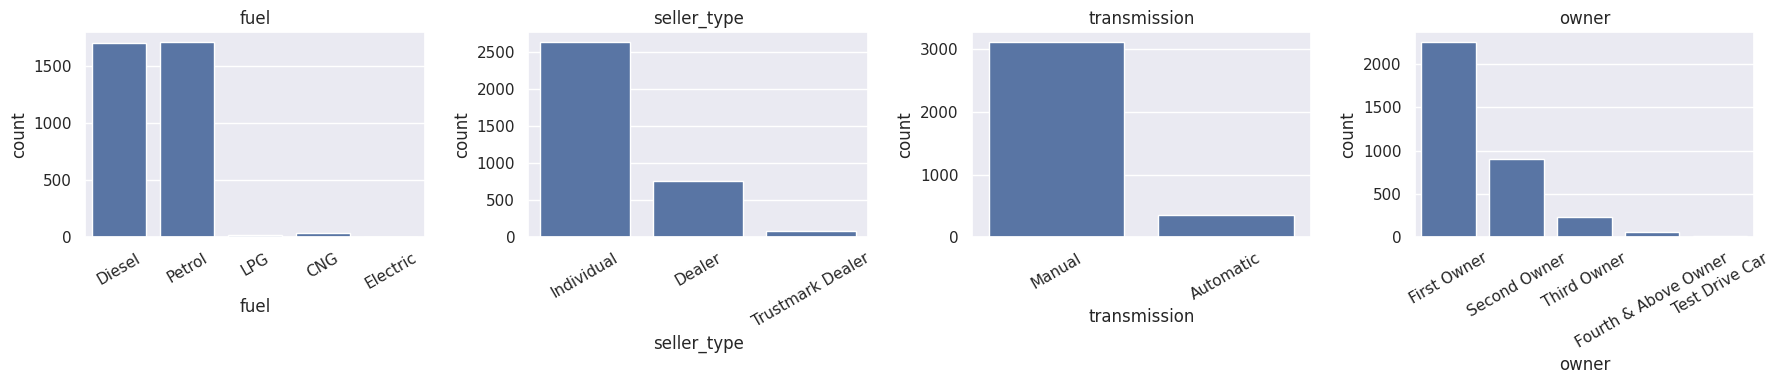

In [9]:
cat_view = ['fuel', 'seller_type', 'transmission', 'owner']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, cat_view):
    sns.countplot(x=col, data=train_df, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

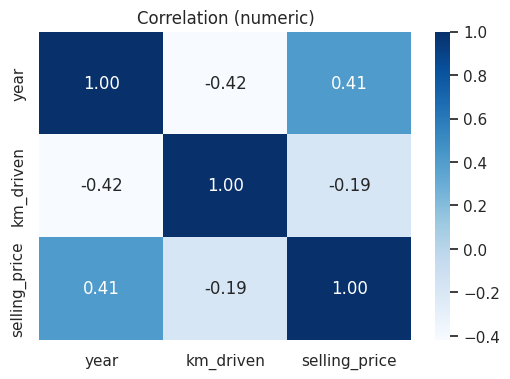

In [10]:
plt.figure(figsize=(6, 4))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation (numeric)')
plt.show()

## 4. Feature Engineering

- `age` = how old the car is (more useful than the raw manufacturing year)
- `brand` = the manufacturer, extracted from the car name (strong price signal)

The same function is applied to train and test.

In [11]:
def add_features(data):
    data = data.copy()
    data['age'] = 2020 - data['year']
    data['brand'] = data['name'].str.split().str[0]
    data = data.drop(columns=['name', 'year'])
    return data

X_train = add_features(X_train)
X_test = add_features(X_test)
X_train.head()

,km_driven,fuel,seller_type,transmission,owner,age,brand
3581,70000,Diesel,Individual,Manual,First Owner,3,Volkswagen
4191,72000,Diesel,Dealer,Manual,First Owner,8,Mahindra
2450,40000,Petrol,Individual,Automatic,First Owner,3,Maruti
984,70000,Diesel,Individual,Manual,First Owner,6,Fiat
3546,35000,Petrol,Individual,Manual,First Owner,2,Maruti


## 5. Encoding (One-Hot for nominal categoricals)

In [12]:
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner', 'brand']

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train = X_train.astype(float)
X_test = X_test.astype(float)
print('Feature count after encoding:', X_train.shape[1])

Feature count after encoding: 41


## 6. Outlier Handling — IQR vs Z-score vs Winsorization (auto-select best)

Applied to the **training set only**, on the continuous columns.

In [13]:
outlier_cols = ['km_driven', 'age']

def cv_score(Xc, yc):
    model = RandomForestRegressor(n_estimators=100, random_state=2)
    return cross_val_score(model, Xc, yc, cv=5, scoring='r2').mean()

def iqr_clean(X, y, cols):
    mask = pd.Series(True, index=X.index)
    for c in cols:
        q1, q3 = X[c].quantile(0.25), X[c].quantile(0.75)
        iqr = q3 - q1
        mask &= X[c].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return X[mask], y[mask]

def zscore_clean(X, y, cols):
    z = np.abs(stats.zscore(X[cols]))
    mask = (z < 3).all(axis=1)
    return X[mask], y[mask]

def winsor_clean(X, y, cols, limit=0.05):
    Xw = X.copy()
    for c in cols:
        Xw[c] = np.asarray(winsorize(Xw[c], limits=[limit, limit]))
    return Xw, y

scores = {}
scores['none'] = cv_score(X_train, y_train)
scores['iqr'] = cv_score(*iqr_clean(X_train, y_train, outlier_cols))
scores['zscore'] = cv_score(*zscore_clean(X_train, y_train, outlier_cols))
scores['winsorize'] = cv_score(*winsor_clean(X_train, y_train, outlier_cols))

for k, v in scores.items():
    print(f'{k:10s} CV R2: {v:.4f}')

best_outlier = max(scores, key=scores.get)
print('\nBest outlier method:', best_outlier)

none       CV R2: 0.7726
iqr        CV R2: 0.7744
zscore     CV R2: 0.7828
winsorize  CV R2: 0.7817

Best outlier method: zscore


In [14]:
if best_outlier == 'iqr':
    X_train, y_train = iqr_clean(X_train, y_train, outlier_cols)
elif best_outlier == 'zscore':
    X_train, y_train = zscore_clean(X_train, y_train, outlier_cols)
elif best_outlier == 'winsorize':
    X_train, y_train = winsor_clean(X_train, y_train, outlier_cols)

print('Training rows after outlier handling:', X_train.shape[0])

Training rows after outlier handling: 3396


## 7. Feature Scaling — Standard vs MinMax vs Robust (auto-select best)

Judged with KNN, since trees/linear are scale-invariant for R².

In [15]:
scalers = {'standard': StandardScaler(), 'minmax': MinMaxScaler(), 'robust': RobustScaler()}

scaler_scores = {}
for name, sc in scalers.items():
    X_scaled = sc.fit_transform(X_train)
    scaler_scores[name] = cross_val_score(KNeighborsRegressor(), X_scaled, y_train, cv=5, scoring='r2').mean()
    print(f'{name:10s} CV R2 (KNN): {scaler_scores[name]:.4f}')

best_scaler_name = max(scaler_scores, key=scaler_scores.get)
print('\nBest scaler:', best_scaler_name)

scaler = scalers[best_scaler_name]
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

standard   CV R2 (KNN): 0.7561
minmax     CV R2 (KNN): 0.7239
robust     CV R2 (KNN): 0.7634

Best scaler: robust


## 8. Model Training & Comparison

In [16]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=2),
    'Gradient Boosting': GradientBoostingRegressor(random_state=2),
    'KNN': KNeighborsRegressor(),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

,Model,R2,MAE,RMSE
0,Random Forest,0.829638,124519.888011,235289.517210
1,Gradient Boosting,0.807043,147593.222664,250406.924874
2,KNN,0.797517,138554.240553,256513.869489
3,Linear Regression,0.652276,189470.410561,336150.119155


In [17]:
best_row = results_df.iloc[0]
print('Best model :', best_row['Model'])
print('Test R2    :', round(best_row['R2'], 4))
print('Test MAE   :', round(best_row['MAE'], 2))
print('Test RMSE  :', round(best_row['RMSE'], 2))

Best model : Random Forest
Test R2    : 0.8296
Test MAE   : 124519.89
Test RMSE  : 235289.52
